In [13]:
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 
import xarray as xr

# Notebook for checking salinity anomalies at five randomly generated timesteps for May 2024

**With scalings to understand the distributions of the salinity**

**The scalings I will be testing are:**

- Min-max scaling
- Normalization with $\mu$ \& $\sigma$
- Max normalization

Will use the scikit funcs for this

In [14]:
filepath_may_anomalies = '/lustre/storeB/project/fou/hi/foccus/malene/ocean-ai/plot/analysis'
checkpoint = 'anomalies_may.nc'


In [15]:
#open ds
ds = xr.open_dataset(f'{filepath_may_anomalies}/{checkpoint}')

In [16]:
# select five random timesteps from May to check variable distribution and the anomaly field
n = 5 
np.random.seed(3030)
random_i = np.random.randint(0, ds.sizes['time'], size = n)
random_ds = ds.isel(time = random_i)

In [17]:
print(random_ds.time)

<xarray.DataArray 'time' (time: 5)> Size: 40B
array(['2024-05-28T03:00:00.000000000', '2024-05-04T20:00:00.000000000',
       '2024-05-04T17:00:00.000000000', '2024-05-20T16:00:00.000000000',
       '2024-05-03T17:00:00.000000000'], dtype='datetime64[ns]')
Coordinates:
  * time     (time) datetime64[ns] 40B 2024-05-28T03:00:00 ... 2024-05-03T17:...
    s_rho    float64 8B ...
    s_w      float64 8B ...
Attributes:
    long_name:      time since initialization
    field:          time, scalar, series
    axis:           T
    standard_name:  time


In [18]:
#Import the dataset with the climatology for salinity in May
file_path_avg = '/lustre/storeB/project/fou/hi/foccus/datasets/norkystv3_averages'
checkpoint_mai_mean = 'norkyst800-202405_avg.nc'
ds_clim = xr.open_dataset(f'{file_path_avg}/{checkpoint_mai_mean}')

In [19]:
#import the associated norkyst files
norkyst_gen_path = '/lustre/storeB/project/fou/hi/foccus/datasets/symlinks/norkystv3-hindcast/2024'

#randomly generated checkpoints of anomalies and their associated norkyst time steps
checkpoint_may_28th = 'norkyst800-20240528.nc' #03:00
checkpoint_may_4th = 'norkyst800-20240504.nc' #20:00
checkpoint_may_4th = 'norkyst800-20240504.nc' #17:00 
checkpoint_may_20th =  'norkyst800-20240520.nc' #16:00 
checkpoint_may_3rd = 'norkyst800-20240503.nc' #17:00 


norkyst_28th = xr.open_dataset(f'{norkyst_gen_path}/{checkpoint_may_28th}').isel(s_rho = -1, time = 3)
norkyst_4th_20 = xr.open_dataset(f'{norkyst_gen_path}/{checkpoint_may_4th}').isel(s_rho = -1, time = 20)
norkyst_4th_17 = xr.open_dataset(f'{norkyst_gen_path}/{checkpoint_may_4th}').isel(s_rho = -1, time = 17)
norkyst_20th = xr.open_dataset(f'{norkyst_gen_path}/{checkpoint_may_20th}').isel(s_rho = -1, time = 16)
norkyst_3rd = xr.open_dataset(f'{norkyst_gen_path}/{checkpoint_may_3rd}').isel(s_rho = -1, time = 17)

In [20]:
norkyst = {
    'day28' : norkyst_28th,
    'day4_20' : norkyst_4th_20,
    'day4_17' : norkyst_4th_17,
    'day20' : norkyst_20th, 
    'day3' : norkyst_3rd
}

"""
#select salinity values
nor_plot = {}
for day, data in norkyst.items():
    nor_plot[day] = data.salinity.values
"""

'\n#select salinity values\nnor_plot = {}\nfor day, data in norkyst.items():\n    nor_plot[day] = data.salinity.values\n'

In [21]:
anomalies_g = {
    'day28' : random_ds.salinity.isel(time = 0).values,
    'day4_20' : random_ds.salinity.isel(time = 1).values,
    'day4_17' : random_ds.salinity.isel(time = 2).values,
    'day20' : random_ds.salinity.isel(time = 3).values,
    'day3' : random_ds.salinity.isel(time = 4).values,
}

In [22]:
import cartopy
import cmocean #using haline cmocean color 
import cartopy.crs as ccrs #cartopy north stereo
from sklearn.preprocessing import MinMaxScaler, StandardScaler, MaxAbsScaler

In [25]:
from scipy import stats

In [43]:
#lets check the distribution of the variables 

def plotting_salinity_w_scaling(norkyst, anomalies_g):

    n_plots = len(norkyst) #5 tidssteg 
    if n_plots == 1:
        axes = [axes] 

    sns.set_theme(style='darkgrid')
    columns_hist = 2 
    fig, axes = plt.subplots(n_plots, columns_hist, figsize = (15, 20), layout = 'compressed')

    for i, (day, data_nor) in enumerate(norkyst.items()):
        anomaly = anomalies_g.get(day, None)
        norkyst_salinity = data_nor.salinity.values
        anomaly_salinity = anomaly if anomaly is not None else np.zeros_like(norkyst_salinity) #if day is missing, a np zeros will be used instead

        #remove nans 
        norkyst_salinity = norkyst_salinity[~np.isnan(norkyst_salinity)]
        anomaly_salinity = anomaly_salinity[~np.isnan(anomaly_salinity)]

    
        #ravel
        norkyst_salinity = norkyst_salinity.ravel()
        anomaly_salinity = anomaly_salinity.ravel()

        """
        #check if they have values: 
        if np.isnan(norkyst_salinity).all():
            raise ValueError(f'All nans retrevied from the Norkyst files')
                #check if they have values: 
        if np.isnan(anomaly_salinity).all():
            raise ValueError(f'All nans retrevied from the Anmoalies files')
        
        if any(x == 0 for x in norkyst_salinity):
            raise ValueError(f'There are zeros retrevied from the Norkyst files')
        if any(x==0 for x in anomaly_salinity):
            raise ValueError(f'There are zeros retrevied from the Anmoalies files')
        """

        #print(norkyst_salinity.reshape(1,-1))
        #print(anomaly_salinity.reshape(1,-1))

        #Employ the minmax scaler 
        scaler = MinMaxScaler()
        minmax_salinity_n = scaler.fit_transform(np.abs(norkyst_salinity).reshape(1,-1)).ravel()
        minmax_salinity_a =scaler.fit_transform(np.abs(anomaly_salinity).reshape(1,-1)).ravel()
        
        scaler1 = StandardScaler()
        standard_salinity_n = scaler1.fit_transform(np.abs(norkyst_salinity).reshape(1,-1)).ravel()
        standard_salinity_a =scaler1.fit_transform(np.abs(anomaly_salinity).reshape(1,-1)).ravel()

        scaler2 = MaxAbsScaler()
        max_salinity_n = scaler2.fit_transform(np.abs(norkyst_salinity).reshape(1,-1)).ravel()
        max_salinity_a = scaler2.fit_transform(np.abs(anomaly_salinity).reshape(1,-1)).ravel()

        non_scaled_salinity_n =  norkyst_salinity
        non_scaled_salinity_a = anomaly_salinity
        
        #im1   
        ax_norkyst_hist = axes[i][0]
        sns.histplot(minmax_salinity_n, bins = 50, kde = False, ax = ax_norkyst_hist, stat = 'density', color = 'royalblue', edgecolor = 'teal', label = 'MinMax')
        sns.histplot(standard_salinity_n, bins = 50, kde = False, ax = ax_norkyst_hist, stat = 'density', color = 'mediumvioletred', edgecolor = 'm', label = 'Standardized')
        sns.histplot(max_salinity_n, bins = 50, kde = False, ax = ax_norkyst_hist, stat = 'density', color = 'indianred', edgecolor = 'firebrick', label = 'Max')
        #sns.histplot(non_scaled_salinity_n, bins = 50, kde = False, ax = ax_norkyst_hist, stat = 'density', color = 'darkseagreen', edgecolor = 'lightgreen', label = 'Unscaled')
        ax_norkyst_hist.set_title(f'{day} - Norkyst with scaling', fontsize = 15) 

        #im2
        ax_anomalies = axes[i][1]
        sns.histplot(minmax_salinity_a, bins = 50, kde = False, ax = ax_anomalies, stat = 'density', color = 'royalblue', edgecolor = 'teal', label = 'MinMax')
        sns.histplot(standard_salinity_a, bins = 50, kde = False, ax = ax_anomalies, stat = 'density', color = 'mediumvioletred', edgecolor = 'm', label = 'Standardized')
        sns.histplot(max_salinity_a, bins = 50, kde = False, ax = ax_anomalies, stat = 'density', color = 'indianred', edgecolor = 'firebrick', label = 'Max')
        #sns.histplot(non_scaled_salinity_a, bins = 50, kde = False, ax = ax_anomalies, stat = 'density', color = 'darkseagreen', edgecolor = 'lightgreen', label = 'Unscaled')
        ax_anomalies.set_title(f'{day} - Anomalies with scaling', fontsize = 15) 
        ax_anomalies.set_xlim(-5,5)

    plt.legend()
    plt.suptitle(f'Histograms of Salinity and Anomalies')
    plt.show()

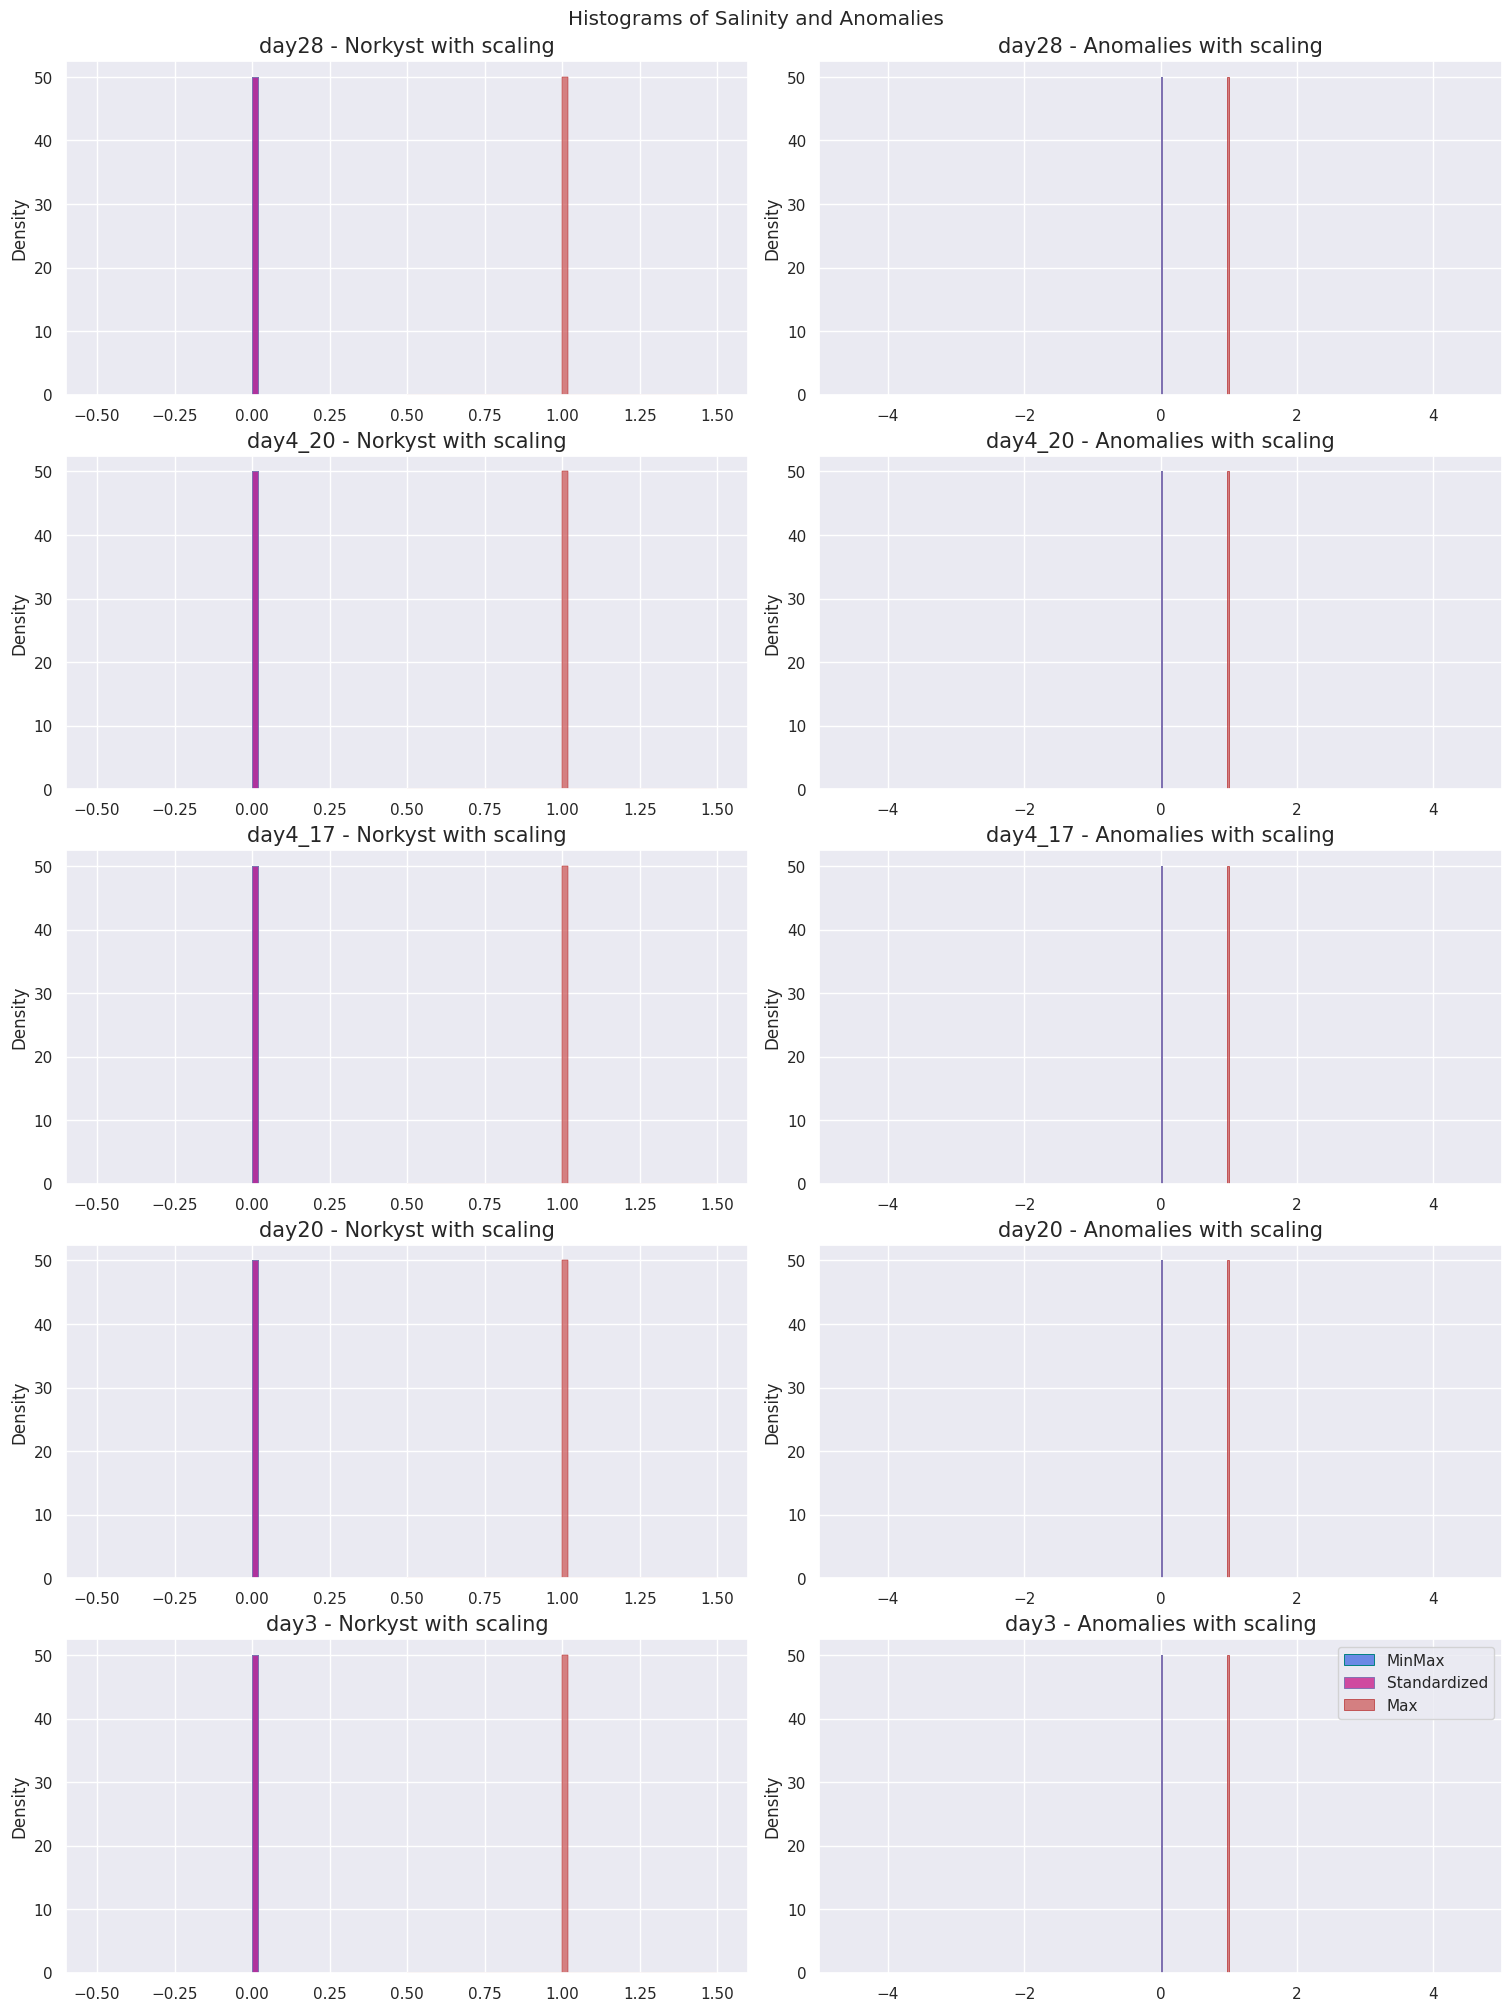

In [44]:
plotting_salinity_w_scaling(norkyst=norkyst, anomalies_g=anomalies_g)

In [41]:
def plotting_salinity_w_scaling_ki(norkyst, anomalies_g):
    import seaborn as sns
    import matplotlib.pyplot as plt
    from sklearn.preprocessing import MinMaxScaler, StandardScaler, MaxAbsScaler
    import numpy as np

    n_plots = len(norkyst)  # 5 tidssteg
    sns.set_theme(style='darkgrid')
    columns_hist = 2
    fig, axes = plt.subplots(n_plots, columns_hist, figsize=(15, 20), layout='compressed')

    for i, (day, data_nor) in enumerate(norkyst.items()):
        anomaly = anomalies_g.get(day, None)
        norkyst_salinity = data_nor.salinity.values
        anomaly_salinity = anomaly if anomaly is not None else np.zeros_like(norkyst_salinity)

        # Fjern NaN-verdier
        norkyst_salinity = norkyst_salinity[~np.isnan(norkyst_salinity)]
        anomaly_salinity = anomaly_salinity[~np.isnan(anomaly_salinity)]

        # Ravel dataene (én-dimensjonale arrays)
        norkyst_salinity = norkyst_salinity.ravel()
        anomaly_salinity = anomaly_salinity.ravel()

        # Sjekk variasjon i dataene
        print(f"Day: {day}")
        print(f"Norkyst: max={norkyst_salinity.max()}, min={norkyst_salinity.min()}, std={norkyst_salinity.std()}")
        print(f"Anomalies: max={anomaly_salinity.max()}, min={anomaly_salinity.min()}, std={anomaly_salinity.std()}")

        # Mini-støy for å håndtere lav variasjon
        noise = np.random.normal(0, 1e-6, size=norkyst_salinity.shape)

        # Skalering
        scaler = MinMaxScaler()
        minmax_salinity_n = scaler.fit_transform((np.abs(norkyst_salinity) + noise).reshape(-1, 1)).ravel()
        minmax_salinity_a = scaler.fit_transform((np.abs(anomaly_salinity) + noise).reshape(-1, 1)).ravel()

        scaler1 = StandardScaler()
        standard_salinity_n = scaler1.fit_transform((np.abs(norkyst_salinity) + noise).reshape(-1, 1)).ravel()
        standard_salinity_a = scaler1.fit_transform((np.abs(anomaly_salinity) + noise).reshape(-1, 1)).ravel()

        scaler2 = MaxAbsScaler()
        max_salinity_n = scaler2.fit_transform((np.abs(norkyst_salinity) + noise).reshape(-1, 1)).ravel()
        max_salinity_a = scaler2.fit_transform((np.abs(anomaly_salinity) + noise).reshape(-1, 1)).ravel()

        non_scaled_salinity_n = norkyst_salinity
        non_scaled_salinity_a = anomaly_salinity

        # Plotting - slå av KDE hvis nødvendig
        ax_norkyst_hist = axes[i][0]
        sns.histplot(minmax_salinity_n, bins=50, kde=False, ax=ax_norkyst_hist, stat='density', color='royalblue', edgecolor='teal', label='MinMax')
        sns.histplot(standard_salinity_n, bins=50, kde=False, ax=ax_norkyst_hist, stat='density', color='mediumvioletred', edgecolor='m', label='Standardized')
        sns.histplot(max_salinity_n, bins=50, kde=False, ax=ax_norkyst_hist, stat='density', color='indianred', edgecolor='firebrick', label='Max')
        #sns.histplot(non_scaled_salinity_n, bins=50, kde=False, ax=ax_norkyst_hist, stat='density', color='darkseagreen', edgecolor='lightgreen', label='Unscaled')
        ax_norkyst_hist.set_title(f'{day} - Norkyst with scaling', fontsize=15)

        ax_anomalies = axes[i][1]
        sns.histplot(minmax_salinity_a, bins=50, kde=False, ax=ax_anomalies, stat='density', color='royalblue', edgecolor='teal', label='MinMax')
        sns.histplot(standard_salinity_a, bins=50, kde=False, ax=ax_anomalies, stat='density', color='mediumvioletred', edgecolor='m', label='Standardized')
        sns.histplot(max_salinity_a, bins=50, kde=False, ax=ax_anomalies, stat='density', color='indianred', edgecolor='firebrick', label='Max')
        #sns.histplot(non_scaled_salinity_a, bins=50, kde=False, ax=ax_anomalies, stat='density', color='darkseagreen', edgecolor='lightgreen', label='Unscaled')
        ax_anomalies.set_title(f'{day} - Anomalies with scaling', fontsize=15)
        ax_anomalies.set_xlim(-5, 5)

    plt.suptitle(f'Histograms of Salinity and Anomalies')
    plt.show()

Day: day28
Norkyst: max=35.23400115966797, min=1.062997817993164, std=3.212841749191284
Anomalies: max=8.196779251098633, min=-17.996248245239258, std=0.865543782711029
Day: day4_20
Norkyst: max=35.2239990234375, min=1.167999267578125, std=2.4919633865356445
Anomalies: max=18.875864028930664, min=-10.664478302001953, std=0.7380061745643616
Day: day4_17
Norkyst: max=35.22200012207031, min=1.2199993133544922, std=2.4756507873535156
Anomalies: max=17.542163848876953, min=-7.940427780151367, std=0.7362041473388672
Day: day20
Norkyst: max=35.255001068115234, min=0.822998046875, std=2.8915905952453613
Anomalies: max=12.415107727050781, min=-15.818443298339844, std=0.5450090765953064
Day: day3
Norkyst: max=35.233001708984375, min=1.3449993133544922, std=2.345879077911377
Anomalies: max=16.739789962768555, min=-7.68409538269043, std=0.8049110770225525


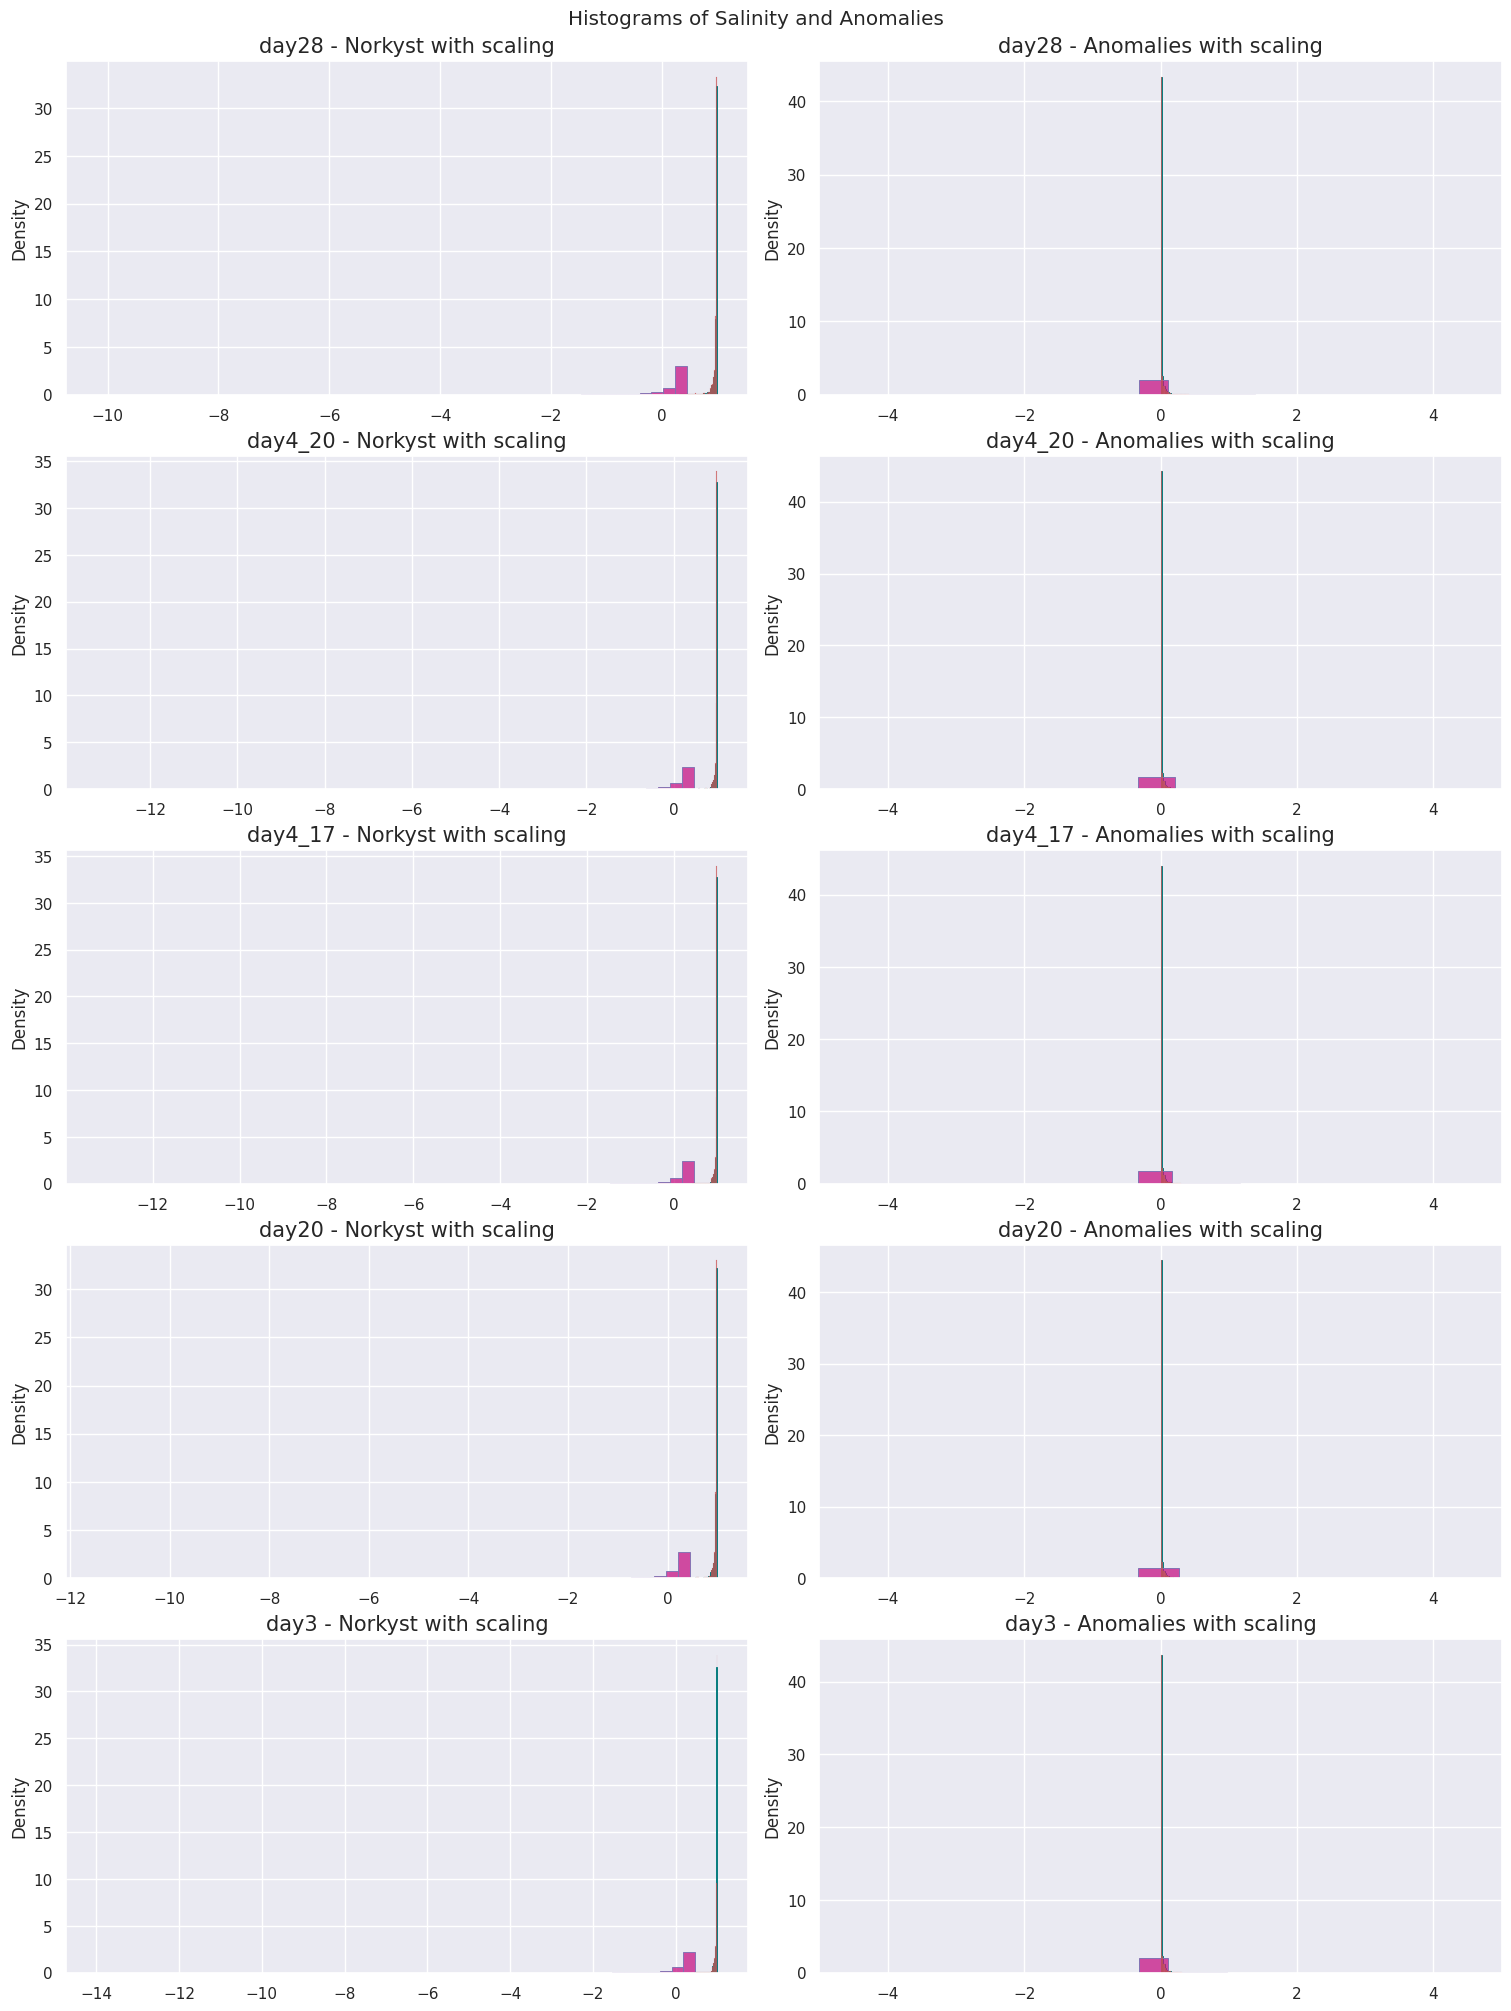

In [42]:
plotting_salinity_w_scaling_ki(norkyst=norkyst, anomalies_g=anomalies_g)

In [ ]:
sns.set_theme(style='darkgrid')
n_plots = len(norkyst)  # 5 tidssteg
columns_hist = 2 
fig, axes = plt.subplots(n_plots, columns_hist, figsize = (15, 20), layout = 'compressed')

for i, (day, data_nor) in enumerate(norkyst.items()):
    anomaly = anomalies_g.get(day, None)
    norkyst_salinity = data_nor.salinity.values
    anomaly_salinity = anomaly if anomaly is not None else np.zeros_like(norkyst_salinity) #if day is missing, a np zeros will be used instead

    #remove nans 
    norkyst_salinity[~np.isnan(norkyst_salinity)]
    anomaly_salinity[~np.isnan(anomaly_salinity)]

    #ravel
    
    norkyst_salinity = norkyst_salinity.ravel()
    anomaly_salinity = anomaly_salinity.ravel()

    #Employ the minmax scaler 
    scaler = MinMaxScaler()
    minmax_salinity_n = scaler.fit_transform(norkyst_salinity)
    minmax_salinity_a = scaler.fit_transform(anomaly_salinity)
    """                                  
    minmax_salinity_n = scaler.fit_transform(np.abs(norkyst_salinity).reshape(1,-1)).ravel()
    minmax_salinity_a =scaler.fit_transform(np.abs(anomaly_salinity).reshape(1,-1)).ravel()
    """

    #im1 
    ax_norkyst_v = axes[i][0]
    im1 = sns.violinplot(minmax_salinity_n, ax = ax_norkyst_v, color = 'royalblue', edgecolor = 'darkolivegreen')
    ax_norkyst_v.set_title(f'{day} - Norkyst', fontsize = 15)

    #im2
    ax_anomalies_v = axes[i][1]
    im1 = sns.violinplot(minmax_salinity_a, ax = ax_anomalies_v, color = 'royalblue', edgecolor = 'darkolivegreen')
    ax_anomalies_v.set_title(f'{day} - Anomalies', fontsize = 15)

plt.suptitle(f'Violin of Salinity and Anomalies')
plt.show()

KeyboardInterrupt: 